In [10]:
from pathlib import Path

rule_files = list(Path("./rulesets").glob("*"))
rule_files

[PosixPath('rulesets/DPA.sleec'),
 PosixPath('rulesets/Aspen.sleec'),
 PosixPath('rulesets/Autocar.sleec'),
 PosixPath('rulesets/ALMI.sleec'),
 PosixPath('rulesets/Safescade.sleec'),
 PosixPath('rulesets/Daisy.sleec'),
 PosixPath('rulesets/AssistiveCareRobot.txt'),
 PosixPath('rulesets/BSN.sleec'),
 PosixPath('rulesets/CSI.sleec'),
 PosixPath('rulesets/DressAssist.sleec')]

In [11]:
def count_unless_clauses(path):
    count = 0
    for line in Path(path).read_text().splitlines():
        if line.strip().lower().startswith("unless"):
            count += 1
    return count


In [12]:
import re
from collections import defaultdict
from pathlib import Path

def extract_normalized_rules_lit(path: Path):
    """
    Normalize literature rules:
    - Parse rules of the form: <id> when <COND> then <OBL>
    - Attach any subsequent 'unless ...' lines to the most recent rule
    - ONLY merge rules that have NO unless-clauses attached
    - Merge is done by identical condition (<COND>), concatenating obligations with ' AND '
    Returns a list of normalized rule dicts: {"condition":..., "obligation":..., "has_unless":...}
    """
    text = path.read_text()
    parsed = []  # list of dicts, in file order

    current = None

    for line in text.splitlines():
        raw = line.strip()
        if not raw or raw.startswith("//"):
            continue
        if raw.lower().startswith("rule_start") or raw.lower().startswith("rule_end"):
            continue

        # Main rule line
        m = re.match(r"^([A-Za-z0-9_]+)\s+when\s+(.*?)\s+then\s+(.*)$", raw, flags=re.IGNORECASE)
        if m:
            current = {
                "id": m.group(1),
                "condition": m.group(2).strip(),
                "obligation": m.group(3).strip(),
                "has_unless": False
            }
            parsed.append(current)
            continue

        # UNLESS line: attaches to previous rule and marks it as non-mergeable
        if raw.lower().startswith("unless") and current is not None:
            current["has_unless"] = True
            continue

    # Group mergeable rules (no unless) by identical condition
    mergeable = defaultdict(list)
    nonmergeable = []

    for r in parsed:
        if r["has_unless"]:
            nonmergeable.append(r)
        else:
            mergeable[r["condition"]].append(r["obligation"])

    normalized = []

    # Add merged rules
    for cond, obligations in mergeable.items():
        merged_obl = " AND ".join(sorted(set(obligations)))
        normalized.append({
            "condition": cond,
            "obligation": merged_obl,
            "has_unless": False
        })

    # Add non-mergeable rules as-is
    for r in nonmergeable:
        normalized.append({
            "condition": r["condition"],
            "obligation": r["obligation"],
            "has_unless": True
        })

    print('Normalized', normalized)
    return normalized


In [13]:
def count_rules(path: Path):
    text = path.read_text()

    # --- SLEEC rules: already normalized by design ---
    if "SLEEC" in text:
        return sum(
            1 for line in text.splitlines()
            if line.strip().startswith("SLEEC")
        )

    # --- Literature rules: normalize first ---
    normalized_rules = extract_normalized_rules_lit(path)
    return len(normalized_rules)


In [14]:
rows = []

for file in Path("./rulesets").glob("*"):
    rules = count_rules(file)
    unless_clauses = count_unless_clauses(file)
    clauses = unless_clauses + 1
    rows.append({
        "Ruleset": file.stem,
        "Rule count": rules,
        "Clause count (ALL)": clauses,
        "Clause count (UNLESS)": unless_clauses,
        "UNLESS per rule": round(unless_clauses / rules, 2) if rules else 0,
        "Clause density": round(clauses / rules, 2) if rules else 0
    })
    
rows.sort(key=lambda d: d.get('Ruleset') == 'AssistiveCareRobot')


rows


Normalized [{'condition': 'DPAMade and (({dpaLength} > 0) or {dpaActive})', 'obligation': 'DPAComplete', 'has_unless': False}, {'condition': 'DPAUpdate and ((not {specificControllerAuth}) or (not {genControllerAuth}))', 'obligation': 'ObtainControllerConsent AND not EngageSubProcessor', 'has_unless': False}, {'condition': 'RightsRequested', 'obligation': 'AssistController AND RespondToRequest', 'has_unless': False}, {'condition': 'RespondToRequest', 'obligation': 'InformSubject', 'has_unless': False}, {'condition': 'DataBreach', 'obligation': 'InformSubject AND InformSupervisor', 'has_unless': False}, {'condition': 'StartDPAProcess and (not {art28Compliance})', 'obligation': 'ProvideControllerInformation', 'has_unless': False}, {'condition': 'AuditsOccur and (((({auditType} = audit) or ({auditType} = inspection)) or ({auditorType} = controller)) or ({auditorType} = mandatedAuditor))', 'obligation': 'AllowAudits AND HelpAuditors', 'has_unless': False}, {'condition': 'EngageSubProcessor'

[{'Ruleset': 'DPA',
  'Rule count': 12,
  'Clause count (ALL)': 3,
  'Clause count (UNLESS)': 2,
  'UNLESS per rule': 0.17,
  'Clause density': 0.25},
 {'Ruleset': 'Aspen',
  'Rule count': 20,
  'Clause count (ALL)': 5,
  'Clause count (UNLESS)': 4,
  'UNLESS per rule': 0.2,
  'Clause density': 0.25},
 {'Ruleset': 'Autocar',
  'Rule count': 39,
  'Clause count (ALL)': 20,
  'Clause count (UNLESS)': 19,
  'UNLESS per rule': 0.49,
  'Clause density': 0.51},
 {'Ruleset': 'ALMI',
  'Rule count': 27,
  'Clause count (ALL)': 9,
  'Clause count (UNLESS)': 8,
  'UNLESS per rule': 0.3,
  'Clause density': 0.33},
 {'Ruleset': 'Safescade',
  'Rule count': 23,
  'Clause count (ALL)': 4,
  'Clause count (UNLESS)': 3,
  'UNLESS per rule': 0.13,
  'Clause density': 0.17},
 {'Ruleset': 'Daisy',
  'Rule count': 23,
  'Clause count (ALL)': 19,
  'Clause count (UNLESS)': 18,
  'UNLESS per rule': 0.78,
  'Clause density': 0.83},
 {'Ruleset': 'BSN',
  'Rule count': 18,
  'Clause count (ALL)': 9,
  'Clause 

In [15]:
!pip install matplotlib pandas -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


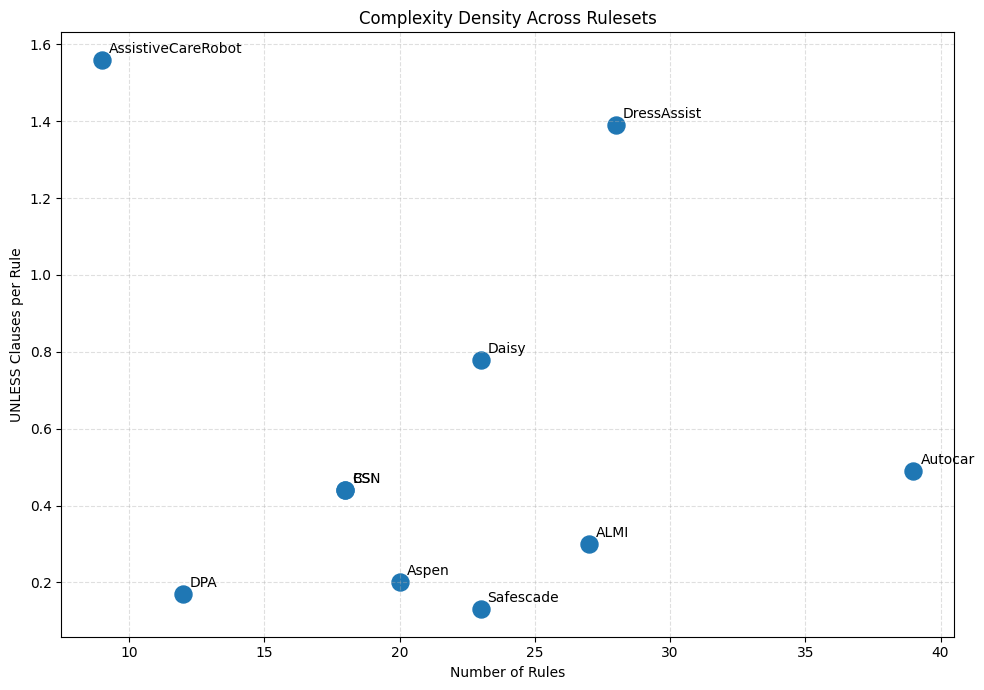

In [16]:
import matplotlib.pyplot as plt

labels = [row["Ruleset"] for row in rows]
rule_counts = [row["Rule count"] for row in rows]
density = [row["UNLESS per rule"] for row in rows]

plt.figure(figsize=(10,7))

# Scatter points
plt.scatter(rule_counts, density, s=150)

# Annotate labels
for i, label in enumerate(labels):
    plt.annotate(label, (rule_counts[i], density[i]), 
                 textcoords="offset points", xytext=(5,5))

plt.xlabel("Number of Rules")
plt.ylabel("UNLESS Clauses per Rule")
plt.title("Complexity Density Across Rulesets")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


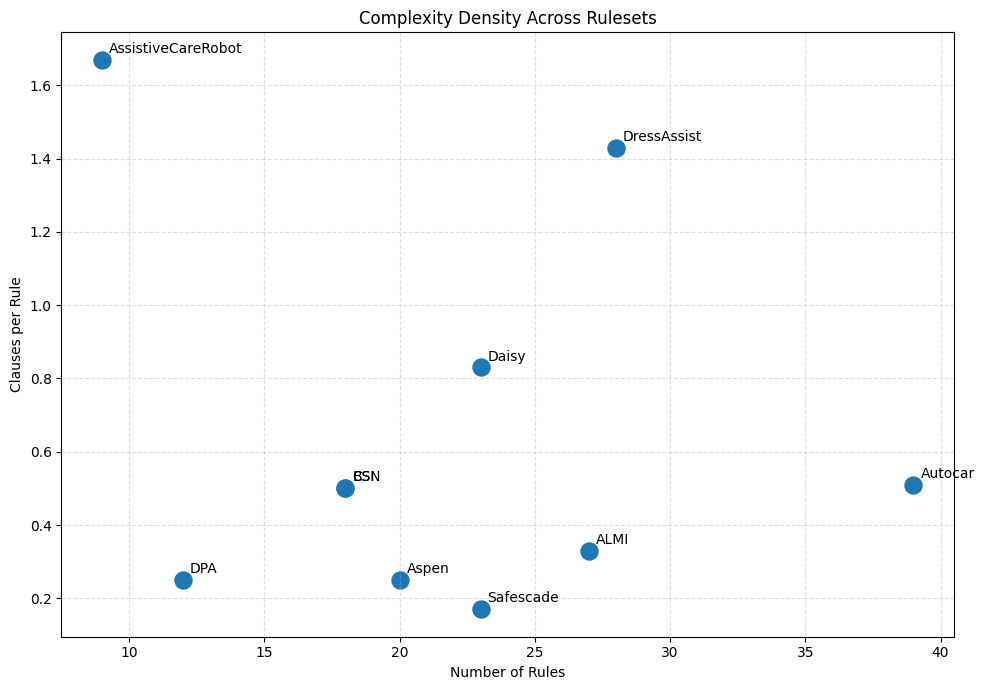

In [17]:
import matplotlib.pyplot as plt

labels = [row["Ruleset"] for row in rows]
rule_counts = [row["Rule count"] for row in rows]
density = [row["Clause density"] for row in rows]

plt.figure(figsize=(10,7))

# Scatter points
plt.scatter(rule_counts, density, s=150)

# Annotate labels
for i, label in enumerate(labels):
    plt.annotate(label, (rule_counts[i], density[i]), 
                 textcoords="offset points", xytext=(5,5))

plt.xlabel("Number of Rules")
plt.ylabel("Clauses per Rule")
plt.title("Complexity Density Across Rulesets")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


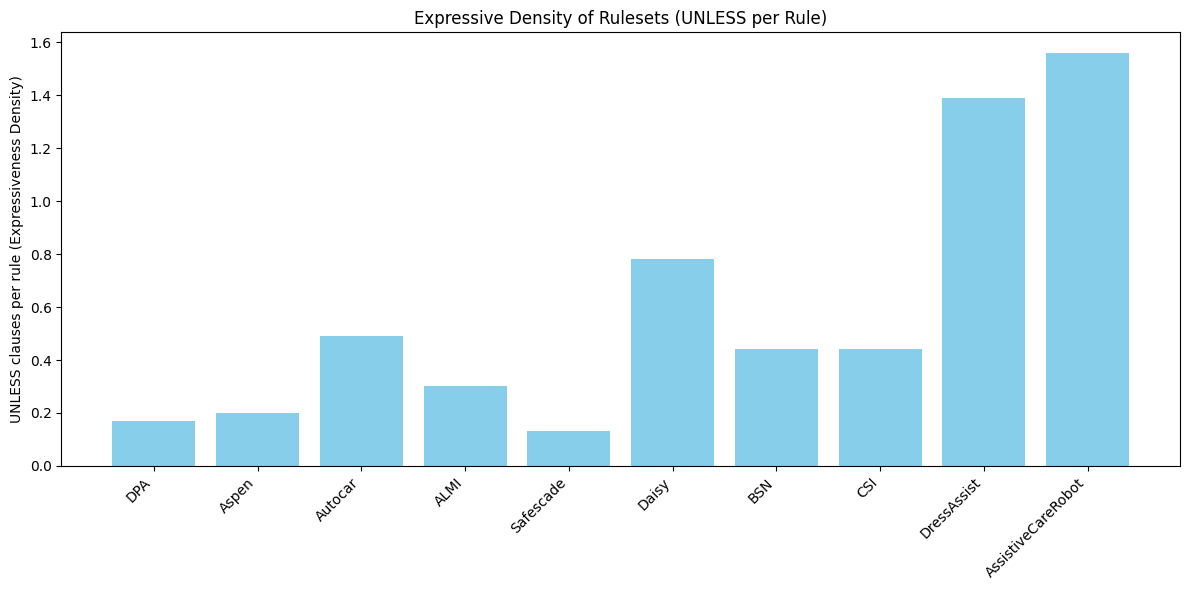

In [18]:
import matplotlib.pyplot as plt

labels = [row["Ruleset"] for row in rows]
density = [row["UNLESS per rule"] for row in rows]

plt.figure(figsize=(12,6))
plt.bar(labels, density, color="skyblue")

plt.ylabel("UNLESS clauses per rule (Expressiveness Density)")
plt.title("Expressive Density of Rulesets (UNLESS per Rule)")
plt.xticks(rotation=45, ha="right")

# Highlight FinalSLEEC
for i, lbl in enumerate(labels):
    if lbl == "FinalSLEEC":
        plt.bar(labels[i], density[i], color="orange")
        plt.text(i, density[i] + 0.05, f"{density[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()


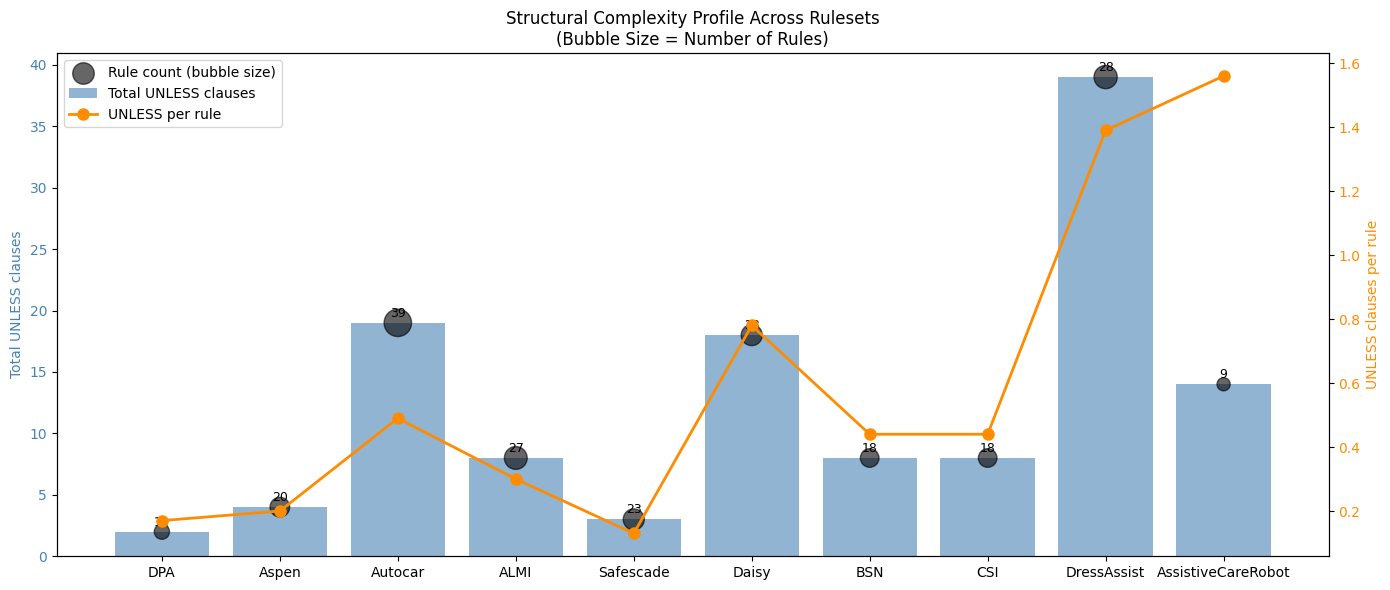

In [19]:
import matplotlib.pyplot as plt
import numpy as np

labels = [row["Ruleset"] for row in rows]
x = np.arange(len(labels))

total_unless = [row["Clause count (UNLESS)"] for row in rows]
density = [row["UNLESS per rule"] for row in rows]
rule_counts = [row["Rule count"] for row in rows]

fig, ax1 = plt.subplots(figsize=(14,6))

# --- BAR PLOT: Total UNLESS ---
bars = ax1.bar(x, total_unless, color="steelblue", alpha=0.6, label="Total UNLESS clauses")
ax1.set_ylabel("Total UNLESS clauses", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")

# --- BUBBLE PLOT: Rule count ---
# scale bubble sizes for visibility
sizes = [r * 10 for r in rule_counts]  
ax1.scatter(x, total_unless, s=sizes, color="black", alpha=0.6, label="Rule count (bubble size)")

# --- TEXT label for rule count near each bubble ---
for i, rc in enumerate(rule_counts):
    ax1.text(x[i], total_unless[i] + 0.5, f"{rc}", ha='center', fontsize=9)

# --- LINE PLOT: UNLESS density ---
ax2 = ax1.twinx()
ax2.plot(x, density, color="darkorange", marker="o",
         linewidth=2, markersize=8, label="UNLESS per rule")
ax2.set_ylabel("UNLESS clauses per rule", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")

# --- X axis labels ---
plt.xticks(x, labels, rotation=45, ha="right")

# --- Title and layout ---
plt.title("Structural Complexity Profile Across Rulesets\n(Bubble Size = Number of Rules)")
fig.tight_layout()

# --- Legend ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
plt.legend(h1 + h2, l1 + l2, loc="upper left")

plt.show()


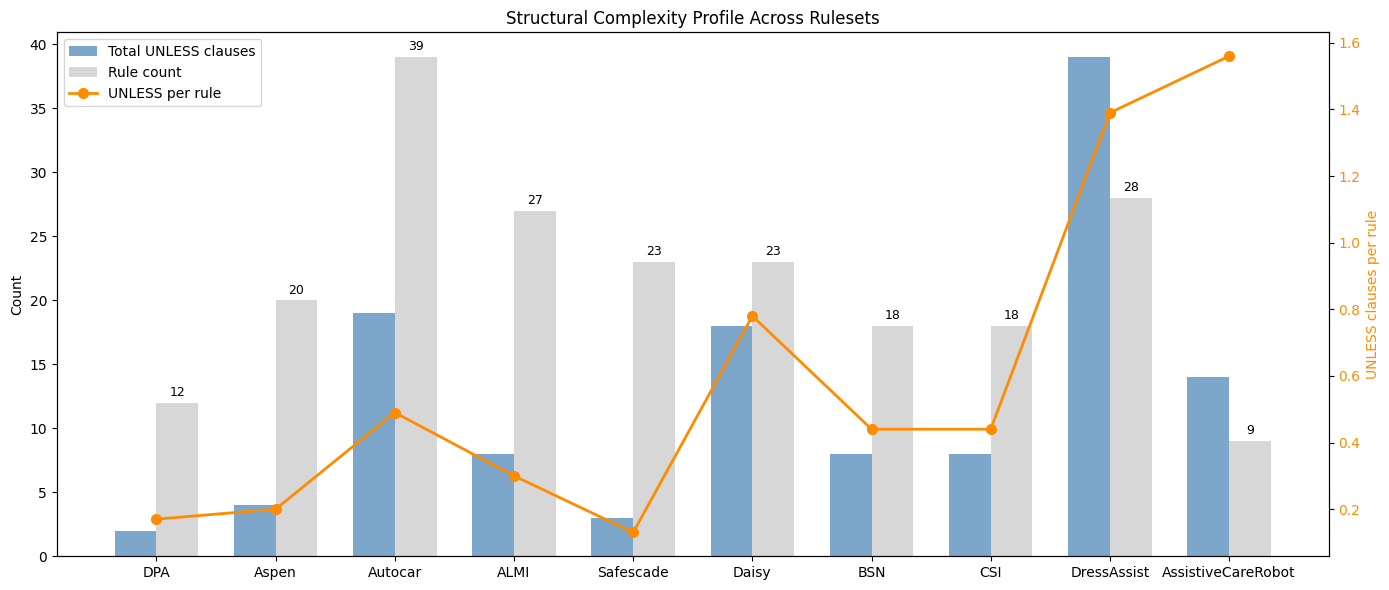

In [20]:
import matplotlib.pyplot as plt
import numpy as np

labels = [row["Ruleset"] for row in rows]
x = np.arange(len(labels))
width = 0.35  # width of bars

total_unless = [row["Clause count (UNLESS)"] for row in rows]
rule_counts = [row["Rule count"] for row in rows]
density = [row["UNLESS per rule"] for row in rows]

fig, ax1 = plt.subplots(figsize=(14,6))

# --- BAR 1: Total UNLESS clauses ---
bars1 = ax1.bar(
    x - width/2,
    total_unless,
    width,
    color="steelblue",
    alpha=0.7,
    label="Total UNLESS clauses"
)

# --- BAR 2: Rule count (contextual) ---
bars2 = ax1.bar(
    x + width/2,
    rule_counts,
    width,
    color="lightgray",
    alpha=0.9,
    label="Rule count"
)

ax1.set_ylabel("Count")
ax1.tick_params(axis='y')

# --- annotate rule counts (subtle) ---
for i, rc in enumerate(rule_counts):
    ax1.text(
        x[i] + width/2,
        rc + 0.3,
        f"{rc}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

# --- LINE: UNLESS per rule (secondary axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    density,
    color="darkorange",
    marker="o",
    linewidth=2,
    markersize=7,
    label="UNLESS per rule"
)
ax2.set_ylabel("UNLESS clauses per rule", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")

# --- X-axis ---
plt.xticks(x, labels, rotation=45, ha="right")

# --- Title ---
plt.title("Structural Complexity Profile Across Rulesets")

# --- Legend (merged) ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
plt.legend(h1 + h2, l1 + l2, loc="upper left")

fig.tight_layout()
plt.show()

contare e confrontare #conditions e #obligations

new: contare total clauses non solo unless clauses e mettere il nostro scenario tutto a dx o sx